In [1]:
import mytransformerlib as mtl
import mylib
import mymachinetranslationlib as mmtl

import torch

loss 0.076, 5468.3 tokens/sec on cuda:0


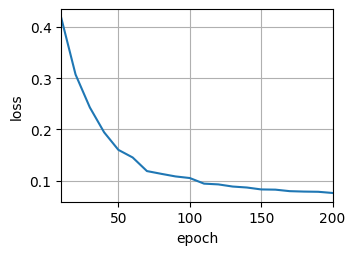

In [2]:
num_hiddens, num_layers, dropout, batch_size, num_steps = 32, 2, 0.1, 64, 10
lr, num_epochs, device = 0.005, 200, mylib.try_gpu()
ffn_num_input, ffn_num_hiddens, num_heads = 32, 64, 4
key_size, query_size, value_size = 32, 32, 32
norm_shape = [32]

train_iter, src_vocab, tgt_vocab = mmtl.load_data_nmt(batch_size, num_steps)

encoder = mtl.TransformerEncoder(
    len(src_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)
decoder = mtl.TransformerDecoder(
    len(tgt_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)
net = mtl.EncoderDecoder(encoder, decoder)
mmtl.train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

In [3]:
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, dec_attention_weight_seq = mmtl.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    #print(f'{eng} => {translation}, ',
          #f'bleu {mmtl.bleu(translation, fra, k=2):.3f}')

In [4]:
X = torch.ones((2, 100, 24))
valid_lens = torch.tensor([3, 2])
encoder_blk = mtl.EncoderBlock(24, 24, 24, 24, [100, 24], 24, 48, 8, 0.5)
encoder_blk.eval()
encoder_blk(X, valid_lens).shape


encoder = mtl.TransformerEncoder(
    200, 24, 24, 24, 24, [100, 24], 24, 48, 8, 2, 0.5)
encoder.eval()
encoder(torch.ones((2, 100), dtype=torch.long), valid_lens).shape


decoder_blk = mtl.DecoderBlock(24, 24, 24, 24, [100, 24], 24, 48, 8, 0.5, 0)
decoder_blk.eval()
X = torch.ones((2, 100, 24))
state = [encoder_blk(X, valid_lens), valid_lens, [None]]
decoder_blk(X, state)[0].shape

torch.Size([2, 100, 24])

True

In [9]:
from collections import defaultdict
dic = defaultdict(int)
print(dic[0], dic[2])
print(dic)
print(3 in dic)
print(dic)

0 0
defaultdict(<class 'int'>, {0: 0, 2: 0})
False
defaultdict(<class 'int'>, {0: 0, 2: 0})
